In [ ]:
import pandas as pd          # Used to read and handle datasets (CSV, Excel, etc.)
import numpy as np          # Used for numerical calculations and arrays
import matplotlib.pyplot as plt  # Used to create graphs and charts
import seaborn as sns       # Used to create attractive statistical visualizations
import zipfile              # Used to extract and work with ZIP files
import os                   # Used to interact with files and folders


In [ ]:
from google.colab import files # Import the files module from Google Colab

uploaded = files.upload() # upload file

Saving nlp-getting-started.zip to nlp-getting-started (2).zip


In [ ]:
zip_path = "/content/nlp-getting-started.zip" #zip file path

with zipfile.ZipFile(zip_path, 'r') as zip_ref:#file reading
    zip_ref.extractall("/content/dataset") #extracting into datatset folder

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
for root, dirs, files in os.walk("/content/dataset"):# Traverse all folders and subfolders
    for file in files:#loop through each file
        print(os.path.join(root, file))#print the file path

/content/dataset/train.csv
/content/dataset/sample_submission.csv
/content/dataset/test.csv


In [ ]:
train_df = pd.read_csv("/content/dataset/train.csv")

test_df = pd.read_csv("/content/dataset/test.csv") # Load the testing dataset into a DataFrame,table-like data structure in Pandas

In [ ]:
train_df.head() #display the first 5 rows of dataset

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
train_df.tail() #display the last 5 rows of dataset

,id,keyword,location,text,target
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1
7612,10873,NaN,NaN,The Latest: More Homes Razed by Northern Calif...,1


In [ ]:
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape) # Print the number of rows and columns in the dataset

Train Shape: (7613, 5)
Test Shape : (3263, 4)


In [ ]:
train_df.info()#Display  information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [ ]:
train_df.isnull().sum()#count missing value in each columns,RET tr if miss

,0
id,0
keyword,61
location,2533
text,0
target,0


In [ ]:
train_df['target'].value_counts()

,count
target,
0,4342
1,3271


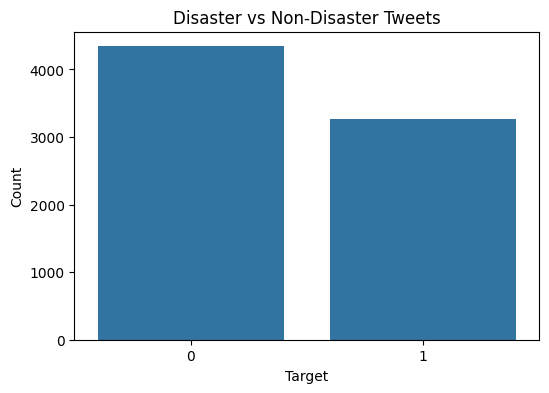

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x='target', data=train_df)

plt.title("Disaster vs Non-Disaster Tweets")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [ ]:
train_df['tweet_length'] = train_df['text'].apply(len)

In [ ]:
train_df[['text','tweet_length']].head()

,text,tweet_length
0,Our Deeds are the Reason of this #earthquake M...,69
1,Forest fire near La Ronge Sask. Canada,38
2,All residents asked to 'shelter in place' are ...,133
3,"13,000 people receive #wildfires evacuation or...",65
4,Just got sent this photo from Ruby #Alaska as ...,88


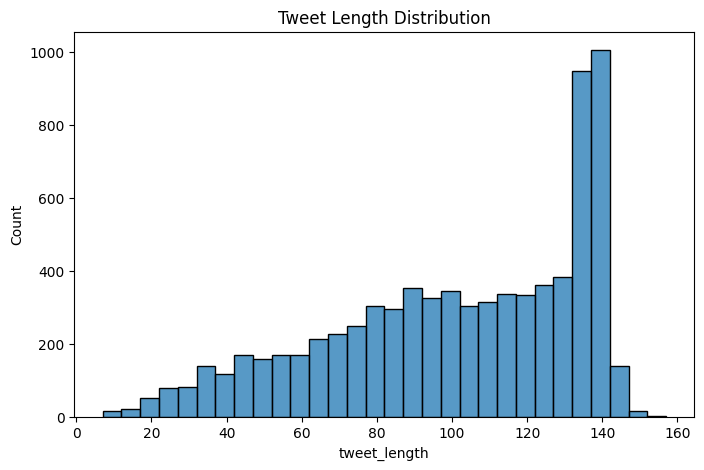

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(train_df['tweet_length'], bins=30)#creates histogram of tweet length and it divides the tweet length into 30 parts for count how many values fall into each interval.

plt.title("Tweet Length Distribution")

plt.show()

In [ ]:
print("Average Length:",
      train_df['tweet_length'].mean())#average tweet length

Average Length: 101.03743596479706


In [ ]:
import nltk
nltk.download('stopwords')#Downloads English stop words(is,am,are)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import re #regular expression(remove unwanted characters)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))#loads the stopwords,convert into set and store in stop_words


In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)#remove until a space found

    text = re.sub(r"[^a-zA-Z ]", "", text)#remove numbers and special characters

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)#covert list to sentence

In [ ]:
train_df['clean_text'] = train_df['text'].apply(clean_text)#clean text

In [ ]:
train_df[['text', 'clean_text']].head(10)#display

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfires pou...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,im top hill see fire woods
8,There's an emergency evacuation happening now ...,theres emergency evacuation happening building...
9,I'm afraid that the tornado is coming to our a...,im afraid tornado coming area


In [ ]:
train_df['clean_text'].isnull().sum()#checks for null value in clean_text

np.int64(0)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer #Term Frequency - Inverse Document Frequency.

tfidf = TfidfVectorizer( #covert text into numbers
    max_features=10000, #max only 10000
    ngram_range=(1,2)#unigram and #bigram
)

X = tfidf.fit_transform(train_df['clean_text'])#Converts each tweet into TF-IDF numbers.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(#split your dataset into two parts Training set and testing set
    X,#tweet data
    y, #Target labels (0 = non-disaster, 1 = disaster)
    test_size=0.2, #20% data for testing, 80% for training
    random_state=42#fixed random split for consistent results
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)#Creates a Logistic Regression model with 1000 iterations to get best solution

model.fit(X_train, y_train)#Train the model

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)#co/to

Accuracy: 0.8003939592908733


In [ ]:
def predict_tweet(tweet):

    cleaned = clean_text(tweet)#clean the tweet

    vector = tfidf.transform([cleaned])#Converts the cleaned tweet into numerical features using the TF-IDF

    prob = model.predict_proba(vector)[0][1]#Predict probability

    print("Disaster Probability:", round(prob,3))

    if prob >= 0.5:
        dtype = detect_disaster_type(tweet)
        return f"🚨 Disaster Tweet\nType: {dtype}"

    return "✅ Not Disaster Tweet"

In [ ]:
def detect_disaster_type(tweet):
    tweet = tweet.lower()

    disaster_types = {
        "Flood": ["flood", "flooding", "submerged"],
        "Earthquake": ["earthquake", "quake", "seismic"],
        "Wildfire": ["wildfire", "forest fire", "bushfire"],
        "Hurricane": ["hurricane", "cyclone", "typhoon"],
        "Tornado": ["tornado"],
        "Explosion": ["explosion", "blast", "exploded"],
        "Building Collapse": ["collapse", "collapsed"],
        "Accident": ["crash", "collision", "derailment"]
    }

    for dtype, keywords in disaster_types.items():
        for word in keywords:#check each keyword in the tweet
            if word in tweet:#if a keyword found in disaster type
                return dtype

    return "Unknown Disaster"

In [ ]:
tweet = input("Enter Tweet: ")

print(predict_tweet(tweet))

Enter Tweet: Train derailment leaves dozens injured near the station.
Disaster Probability: 0.846
🚨 Disaster Tweet
Type: Accident
